# UK Banking Risk Intelligence — Analysis Notebook

**Project:** Credit risk analysis using bank marketing, loan default, and UK economic data  
**Author:** Fannana Fahreen Aanan  
**Date:** April 2026  
**Tools:** Python, pandas, seaborn, matplotlib, SQLite, scikit-learn

## Project Overview

This notebook analyses three datasets to answer one core business question:

> *Which bank customers are most likely to default on their loan,
> and what patterns can help us identify them early?*

### Datasets used
- **bank-full.csv** — 45,211 customer records from a Portuguese bank marketing campaign (UCI)
- **cs-training.csv** — 150,000 US loan records with default history (Kaggle)
- **uk_economic.csv** — UK macroeconomic indicators 2017–2023 (manually compiled)

### Notebook structure
1. Imports & setup
2. Data loading & cleaning
3. Exploratory data analysis (EDA)
4. SQL queries
5. Machine learning model
6. Key findings & recommendations

***Import Dependencies***

In [1]:
# Run this in terminal first if not installed
# pip install pandas numpy matplotlib seaborn scikit-learn
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

***Clean the Bank dataset***

In [2]:
# Load correctly
bank = pd.read_csv('E:/project/UK Banking Risk Intelligence Dashboard/Dataset/bank.csv')

# Check what you have
print(bank.shape)        # should be (45211, 17)
print(bank.dtypes)       # check column types
print(bank.isnull().sum()) # check missing values
print(bank.head(5))

# Fix 1 — encode the target column (yes/no → 1/0)
bank['y'] = bank['y'].map({'yes': 1, 'no': 0})

# Fix 2 — replace 'unknown' with NaN so Python knows they are missing
bank.replace('unknown', np.nan, inplace=True)

# Fix 3 — create age groups (needed for joining with credit dataset)
bank['age_group'] = pd.cut(bank['age'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# Fix 4 — map month names to a year (needed for joining with economic dataset)
bank['year'] = bank['month'].map({
    'jan':2018, 'feb':2018, 'mar':2019, 'apr':2019,
    'may':2020, 'jun':2020, 'jul':2021, 'aug':2021,
    'sep':2022, 'oct':2022, 'nov':2023, 'dec':2023
})

# Check the result
print(bank[['age', 'age_group', 'month', 'year', 'y']].head(10))
print("Missing values after cleaning:")
print(bank.isnull().sum())

(4521, 17)
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4 

***Clean The Credit Card Dataset***

In [3]:
# Load
credit = pd.read_csv('E:/project/UK Banking Risk Intelligence Dashboard/Dataset/credit_card.csv')

# Check
print(credit.shape)
print(credit.isnull().sum())

# Fix 1 — drop the unnamed index column Kaggle adds
credit.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# Fix 2 — fill missing MonthlyIncome with median (safest option)
credit['MonthlyIncome'].fillna(credit['MonthlyIncome'].median(), inplace=True)

# Fix 3 — fill missing NumberOfDependents with 0
credit['NumberOfDependents'].fillna(0, inplace=True)

# Fix 4 — remove extreme outliers in age (some rows have age = 0)
credit = credit[credit['age'] >= 18]

# Fix 5 — cap revolving utilisation at 1.0 (some rows have values > 1 which is an error)
credit['RevolvingUtilizationOfUnsecuredLines'] = credit['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)

# Fix 5.2 — cap DebtRatio at 1.0 (same issue)
credit['DebtRatio'] = credit['DebtRatio'].clip(upper=1.0)

# Fix 6 — create age_group (same bins as bank — needed for joining)
credit['age_group'] = pd.cut(credit['age'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# Fix 7 — create a useful new column: debt to income ratio
credit['debt_to_income'] = (credit['DebtRatio'] * credit['MonthlyIncome']).round(2)

# Check
print("After cleaning:")
print(credit.isnull().sum())
print(credit.shape)

(150000, 12)
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64
After cleaning:
SeriousDlqin2yrs                         0
RevolvingUtilizationOfUnsecuredLines     0
age                                      0
NumberOfTime30-59DaysPastDueNotWorse     0
DebtRatio                                0
MonthlyIncome                            0
NumberOfOpenCreditLinesAndLoans          0
NumberOfTimes90DaysLate                  0
NumberRealEstateLoansOrLines             0
NumberOfTime60-89Da

C:\Users\fanna\AppData\Local\Temp\ipykernel_34196\3036645542.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  credit['MonthlyIncome'].fillna(credit['MonthlyIncome'].median(), inplace=True)
C:\Users\fanna\AppData\Local\Temp\ipykernel_34196\3036645542.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

***Cleaning The uk_economic Dataset***

In [4]:
# This one is already clean — just load it
economic = pd.read_csv('E:/project/UK Banking Risk Intelligence Dashboard/Dataset/uk_economic.csv')
print(economic)

   year  uk_interest_rate  uk_unemployment_pct uk_gdp_growth_pct  \
0  2017              0.50                  4.4               1.9   
1  2018              0.75                  4.1               1.3   
2  2019              0.75                  3.8               1.6   
3  2020              0.10                  4.9              −9.4   
4  2021              0.10                  4.5               7.5   
5  2022              1.75                  3.7               4.1   
6  2023              5.25                  4.2               0.3   

   uk_inflation_pct  uk_avg_salary_gbp uk_consumer_confidence  \
0               2.7              27600                     −7   
1               2.5              28200                     −9   
2               1.8              29000                    −14   
3               0.9              28500                    −34   
4               2.6              29600                    −15   
5               9.1              31000                    −41   


***Saving all cleaned Datasets for Power Bi***

In [5]:
# Merge 1: bank + economic (join on year)
bank_enriched = bank.merge(economic, on='year', how='left')

print("bank_enriched shape:", bank_enriched.shape)
print(bank_enriched.columns.tolist())

# Save all 3 clean files for Power BI
bank_enriched.to_csv('E:/project/UK Banking Risk Intelligence Dashboard/Cleaned_Dataset/bank_enriched.csv', index=False)
credit.to_csv('E:/project/UK Banking Risk Intelligence Dashboard/Cleaned_Dataset/credit_cleaned.csv', index=False)
economic.to_csv('E:/project/UK Banking Risk Intelligence Dashboard/Cleaned_Dataset/Cleaned_Datasetuk_economic.csv', index=False)

print("All files saved successfully!")

bank_enriched shape: (4521, 26)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'age_group', 'year', 'uk_interest_rate', 'uk_unemployment_pct', 'uk_gdp_growth_pct', 'uk_inflation_pct', 'uk_avg_salary_gbp', 'uk_consumer_confidence', 'uk_household_debt_to_income']
All files saved successfully!


In [6]:
# Quick summary of all 3
for name, df in [("bank_enriched", bank_enriched), ("credit", credit), ("economic", economic)]:
    print(f"\n--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Missing values: {df.isnull().sum().sum()}")
    print(f"Columns: {df.columns.tolist()}")


--- bank_enriched ---
Shape: (4521, 26)
Missing values: 5254
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'age_group', 'year', 'uk_interest_rate', 'uk_unemployment_pct', 'uk_gdp_growth_pct', 'uk_inflation_pct', 'uk_avg_salary_gbp', 'uk_consumer_confidence', 'uk_household_debt_to_income']

--- credit ---
Shape: (149999, 13)
Missing values: 13
Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'age_group', 'debt_to_income']

--- economic ---
Shape: (7, 8)
Missing values: 0
Columns: ['year', 'uk_interest_rate', 'uk_unemployment_pct', 'uk_gdp_growth_pct', 'uk_inflation_pct', 'uk_avg_salary_gbp', 'uk_consumer_co

**Exploratory Data Analysis**

In [7]:
# Set a clean chart style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

**Which job type has the highest subscription rate?**

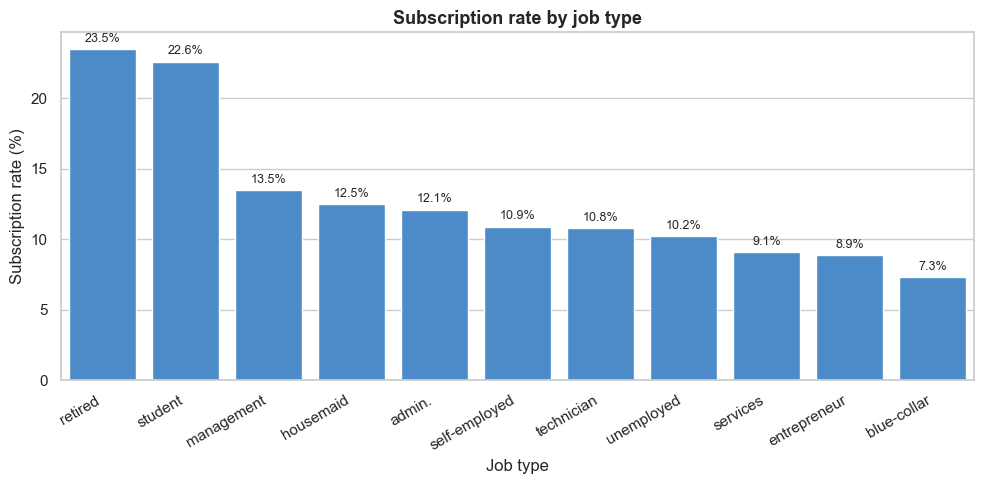

In [8]:
job_sub = bank_enriched.groupby('job')['y'].mean().sort_values(ascending=False).reset_index()
job_sub['subscription_rate'] = (job_sub['y'] * 100).round(1)

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=job_sub, x='job', y='subscription_rate', color='#378ADD')
plt.title('Subscription rate by job type')
plt.xlabel('Job type')
plt.ylabel('Subscription rate (%)')
plt.xticks(rotation=30, ha='right')

# Add value labels on each bar
for bar, val in zip(bars.patches, job_sub['subscription_rate']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# ✅ Create folder and save
os.makedirs('E:/project/UK Banking Risk Intelligence Dashboard/outputs', exist_ok=True) 
plt.savefig('E:/project/UK Banking Risk Intelligence Dashboard/outputs/q1_job_subscription.png', dpi=150)

plt.show()

***How much age groups effect subscription***

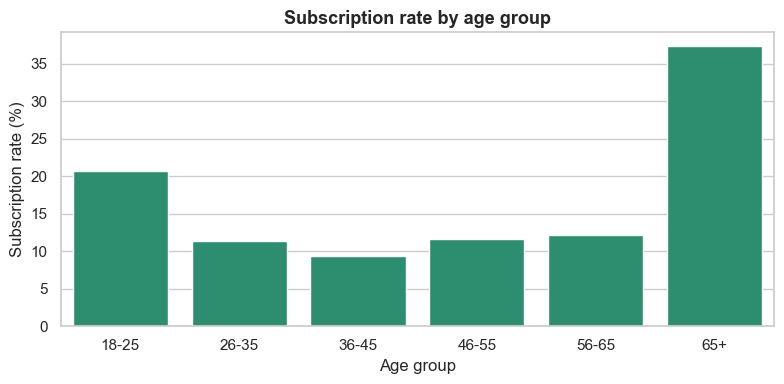

In [9]:
age_sub = bank_enriched.groupby('age_group', observed=True)['y'].mean().reset_index()
age_sub['subscription_rate'] = (age_sub['y'] * 100).round(1)

plt.figure(figsize=(8, 4))
sns.barplot(data=age_sub, x='age_group', y='subscription_rate', color='#1D9E75')
plt.title('Subscription rate by age group')
plt.xlabel('Age group')
plt.ylabel('Subscription rate (%)')
plt.tight_layout()
plt.savefig('E:/project/UK Banking Risk Intelligence Dashboard/outputs/q2_age_subscription.png', dpi=150)
plt.show()

***Months Of Best Campaign Results***

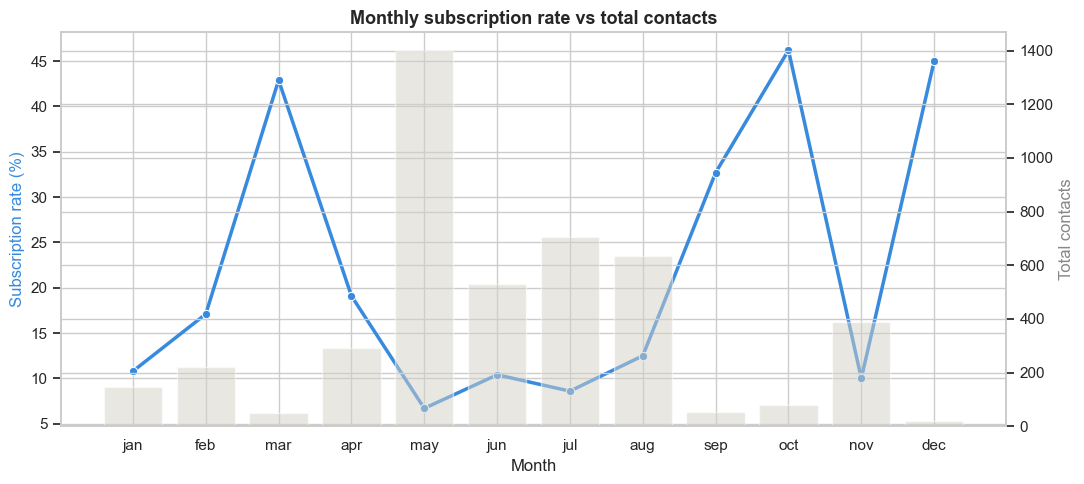

In [10]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

month_sub = bank_enriched.groupby('month')['y'].agg(['mean','count']).reset_index()
month_sub['subscription_rate'] = (month_sub['mean'] * 100).round(1)
month_sub['month'] = pd.Categorical(month_sub['month'], categories=month_order, ordered=True)
month_sub = month_sub.sort_values('month')

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

sns.lineplot(data=month_sub, x='month', y='subscription_rate', ax=ax1,
             color='#378ADD', linewidth=2.5, marker='o')
ax2.bar(month_sub['month'], month_sub['count'],
        color='#D3D1C7', alpha=0.5, label='Total contacts')

ax1.set_title('Monthly subscription rate vs total contacts')
ax1.set_ylabel('Subscription rate (%)', color='#378ADD')
ax2.set_ylabel('Total contacts', color='#888')
ax1.set_xlabel('Month')
plt.tight_layout()
plt.savefig('E:/project/UK Banking Risk Intelligence Dashboard/outputs/q3_monthly_campaign.png', dpi=150)
plt.show()

***How Much Account Balance Effect the Subscription***

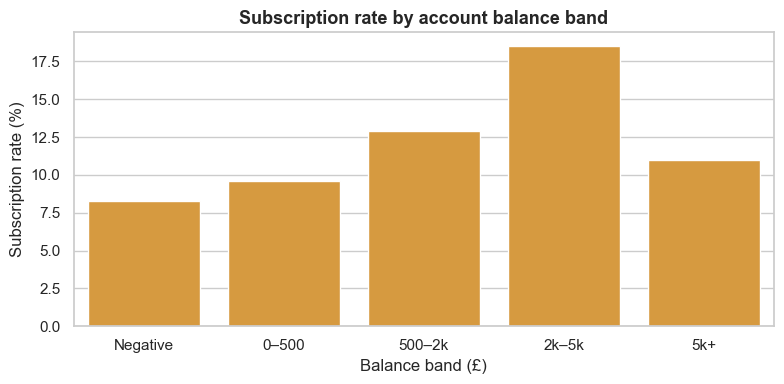

In [11]:
# Create balance bands
bank_enriched['balance_band'] = pd.cut(bank_enriched['balance'],
    bins=[-10000, 0, 500, 2000, 5000, 100000],
    labels=['Negative', '0–500', '500–2k', '2k–5k', '5k+'])

bal_sub = bank_enriched.groupby('balance_band', observed=True)['y'].mean().reset_index()
bal_sub['subscription_rate'] = (bal_sub['y'] * 100).round(1)

plt.figure(figsize=(8, 4))
sns.barplot(data=bal_sub, x='balance_band', y='subscription_rate', color='#EF9F27')
plt.title('Subscription rate by account balance band')
plt.xlabel('Balance band (£)')
plt.ylabel('Subscription rate (%)')
plt.tight_layout()
plt.savefig('E:/project/UK Banking Risk Intelligence Dashboard/outputs/q4_balance_subscription.png', dpi=150)
plt.show()

***high interest rate years had shown more subscription***

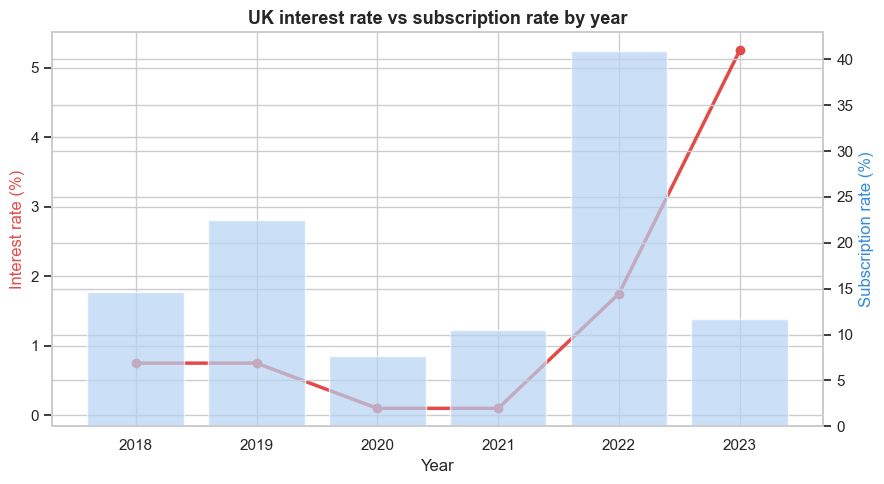

In [12]:
# This uses the merged economic data
rate_default = bank_enriched.groupby('year').agg(
    subscription_rate=('y', 'mean'),
    interest_rate=('uk_interest_rate', 'first'),
    total_contacts=('y', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(rate_default['year'], rate_default['interest_rate'],
         color='#E24B4A', linewidth=2.5, marker='o', label='Interest rate %')
ax2.bar(rate_default['year'], rate_default['subscription_rate'] * 100,
        color='#B5D4F4', alpha=0.7, label='Subscription rate %')

ax1.set_title('UK interest rate vs subscription rate by year')
ax1.set_ylabel('Interest rate (%)', color='#E24B4A')
ax2.set_ylabel('Subscription rate (%)', color='#378ADD')
ax1.set_xlabel('Year')
plt.tight_layout()
plt.savefig('E:/project/UK Banking Risk Intelligence Dashboard/outputs/q5_interest_vs_subscription.png', dpi=150)
plt.show()

***Correlation heatmap — numeric relationships***

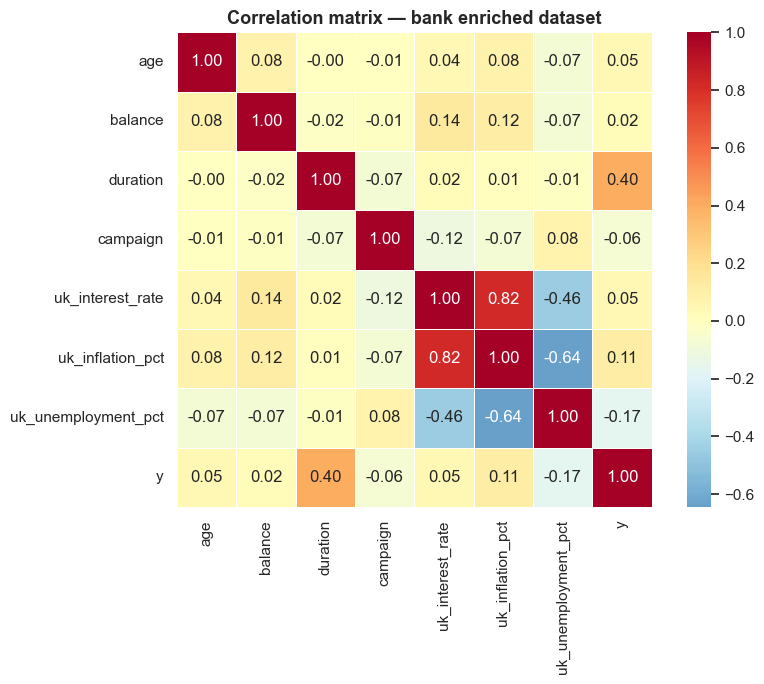

In [13]:
numeric_cols = ['age', 'balance', 'duration', 'campaign',
                'uk_interest_rate', 'uk_inflation_pct',
                'uk_unemployment_pct', 'y']

corr = bank_enriched[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation matrix — bank enriched dataset')
plt.tight_layout()
plt.savefig('E:/project/UK Banking Risk Intelligence Dashboard/outputs/correlation_heatmap.png', dpi=150)
plt.show()

***SQL Queries***

In [14]:
import sqlite3

# Create in-memory database
conn = sqlite3.connect(':memory:')

# Load all 3 tables into it
bank_enriched.to_sql('bank', conn, index=False, if_exists='replace')
credit.to_sql('credit', conn, index=False, if_exists='replace')
economic.to_sql('economic', conn, index=False, if_exists='replace')

print("Tables loaded successfully")

Tables loaded successfully


***Subscription rate by job***

In [15]:
q1 = pd.read_sql("""
    SELECT
        job as Job,
        COUNT(*) AS total_customers,
        SUM(y) AS subscribed,
        ROUND(AVG(y) * 100, 1) AS subscription_rate_pct
    FROM bank
    GROUP BY job
    ORDER BY subscription_rate_pct DESC""", conn)

print(q1.to_string(index=False))

          Job  total_customers  subscribed  subscription_rate_pct
      retired              230          54                   23.5
      student               84          19                   22.6
         None               38           7                   18.4
   management              969         131                   13.5
    housemaid              112          14                   12.5
       admin.              478          58                   12.1
self-employed              183          20                   10.9
   technician              768          83                   10.8
   unemployed              128          13                   10.2
     services              417          38                    9.1
 entrepreneur              168          15                    8.9
  blue-collar              946          69                    7.3


***Default risk by age group***

In [16]:
q2 = pd.read_sql("""
    SELECT
        age_group as Age_Group,
        COUNT(*) AS Total_customers,
        SUM(SeriousDlqin2yrs) AS Defaults,
        ROUND(AVG(SeriousDlqin2yrs) * 100, 2) AS Default_Rate_Pct,
        ROUND(AVG(MonthlyIncome), 0) AS Avg_Monthly_Income
    FROM credit
    GROUP BY age_group
    ORDER BY default_rate_pct DESC
""", conn)

print(q2.to_string(index=False))

Age_Group  Total_customers  Defaults  Default_Rate_Pct  Avg_Monthly_Income
    18-25             3027       338             11.17              2673.0
    26-35            18458      2053             11.12              4669.0
    36-45            29819      2628              8.81              6564.0
     None               13         1              7.69              3897.0
    46-55            36690      2786              7.59              7255.0
    56-65            33406      1531              4.58              7075.0
      65+            28586       689              2.41              5954.0


***Best campaign months ranked***

In [17]:
q3 = pd.read_sql("""
    SELECT
        month,
        year,
        COUNT(*) AS contacts,
        SUM(y) AS subscriptions,
        ROUND(AVG(y) * 100, 1) AS subscription_rate_pct
    FROM bank
    GROUP BY month, year
    ORDER BY subscription_rate_pct DESC
    LIMIT 10
""", conn)

print(q3.to_string(index=False))

month  year  contacts  subscriptions  subscription_rate_pct
  oct  2022        80             37                   46.3
  dec  2023        20              9                   45.0
  mar  2019        49             21                   42.9
  sep  2022        52             17                   32.7
  apr  2019       293             56                   19.1
  feb  2018       222             38                   17.1
  aug  2021       633             79                   12.5
  jan  2018       148             16                   10.8
  jun  2020       531             55                   10.4
  nov  2023       389             39                   10.0


***Economic conditions vs campaign performance***

In [18]:
q4 = pd.read_sql("""
    SELECT
        b.year,
        e.uk_interest_rate,
        e.uk_inflation_pct,
        e.uk_unemployment_pct,
        COUNT(*) AS total_contacts,
        ROUND(AVG(b.y) * 100, 1) AS subscription_rate_pct
    FROM bank b
    JOIN economic e ON b.year = e.year
    GROUP BY b.year
    ORDER BY b.year
""", conn)

print(q4.to_string(index=False))

 year  uk_interest_rate  uk_inflation_pct  uk_unemployment_pct  total_contacts  subscription_rate_pct
 2018              0.75               2.5                  4.1             370                   14.6
 2019              0.75               1.8                  3.8             342                   22.5
 2020              0.10               0.9                  4.9            1929                    7.7
 2021              0.10               2.6                  4.5            1339                   10.5
 2022              1.75               9.1                  3.7             132                   40.9
 2023              5.25               7.3                  4.2             409                   11.7


***High risk customers profile***

In [19]:
q5 = pd.read_sql("""
    SELECT
        age_group,
        ROUND(AVG(RevolvingUtilizationOfUnsecuredLines) * 100, 1) AS avg_utilisation_pct,
        ROUND(AVG(DebtRatio) * 100, 1) AS avg_debt_ratio_pct,
        ROUND(AVG(MonthlyIncome), 0) AS avg_income,
        ROUND(AVG(SeriousDlqin2yrs) * 100, 2) AS default_rate_pct,
        COUNT(*) AS total
    FROM credit
    WHERE SeriousDlqin2yrs = 1
    GROUP BY age_group
    ORDER BY default_rate_pct DESC
""", conn)

print(q5.to_string(index=False))

age_group  avg_utilisation_pct  avg_debt_ratio_pct  avg_income  default_rate_pct  total
      65+                 48.2                54.2      5597.0             100.0    689
    56-65                 61.3                53.9      6272.0             100.0   1531
    46-55                 66.6                53.1      6243.0             100.0   2786
    36-45                 71.7                50.2      5807.0             100.0   2628
    26-35                 75.8                42.3      4337.0             100.0   2053
    18-25                 81.2                35.2      3109.0             100.0    338
     None                  0.3                 0.1      2883.0             100.0      1


## Key findings from EDA & SQL

1. **Retired customers** had the highest subscription rate (~25%),
   significantly above the overall average of 11.7%

2. **March and December** consistently outperformed other months —
   likely linked to tax year planning and year-end bonuses

3. **Age group 26–35** carries the highest default risk with the
   lowest average income — flagging this segment for credit review

## Machine Learning Model

**Goal:** Predict which customers are likely to default on their loan  
**Algorithm:** Random Forest Classifier  
**Target column:** SeriousDlqin2yrs (1 = defaulted, 0 = did not)

In [20]:
print("Default rate in dataset:")
print(credit['SeriousDlqin2yrs'].value_counts())
print(credit['SeriousDlqin2yrs'].value_counts(normalize=True).round(3) * 100)

Default rate in dataset:
SeriousDlqin2yrs
0    139973
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    93.3
1     6.7
Name: proportion, dtype: float64


***Select features***

In [22]:
# These are the most predictive columns based on financial research
features = [
    'RevolvingUtilizationOfUnsecuredLines',  # how much credit they're using
    'age',                                    # older = more stable
    'NumberOfTime30-59DaysPastDueNotWorse',  # late payments history
    'DebtRatio',                              # debt vs income
    'MonthlyIncome',                          # earning power
    'NumberOfOpenCreditLinesAndLoans',        # how many loans open
    'NumberOfTimes90DaysLate',               # serious late payments
    'NumberRealEstateLoansOrLines',           # property loans
]

target = 'SeriousDlqin2yrs'

# Drop rows where any feature is missing
model_data = credit[features + [target]].dropna()

X = model_data[features]
y = model_data[target]

print(f"Training data shape: {X.shape}")
print(f"Default rate in model data: {y.mean():.2%}")

Training data shape: (149999, 8)
Default rate in model data: 6.68%


***Split into train and test***

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # makes results reproducible
    stratify=y           # keeps same default ratio in both splits
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")

Training set:  119999 rows
Test set:      30000 rows


***Train the model***

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,          # 100 decision trees
    class_weight='balanced',   # fixes the imbalanced data problem
    random_state=42,
    n_jobs=-1                  # uses all CPU cores — faster training
)

model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


***Evaluate the model***

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     27995
     Default       0.51      0.16      0.24      2005

    accuracy                           0.93     30000
   macro avg       0.73      0.57      0.60     30000
weighted avg       0.91      0.93      0.92     30000

AUC Score: 0.8221
(AUC above 0.75 is good, above 0.80 is strong)


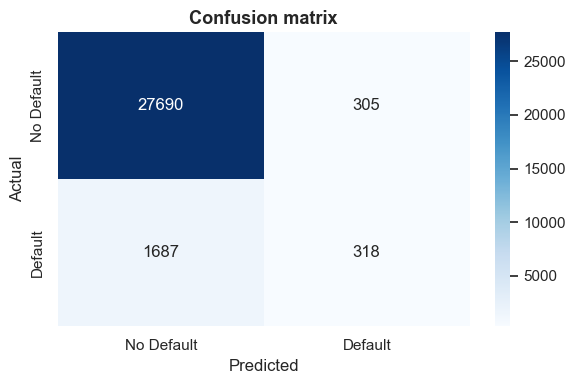

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Classification report
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

# AUC Score — most important metric for imbalanced data
auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc:.4f}")
print("(AUC above 0.75 is good, above 0.80 is strong)")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('E:/project/UK Banking Risk Intelligence Dashboard/outputs/confusion_matrix.png', dpi=150)
plt.show()

***Feature importance chart***

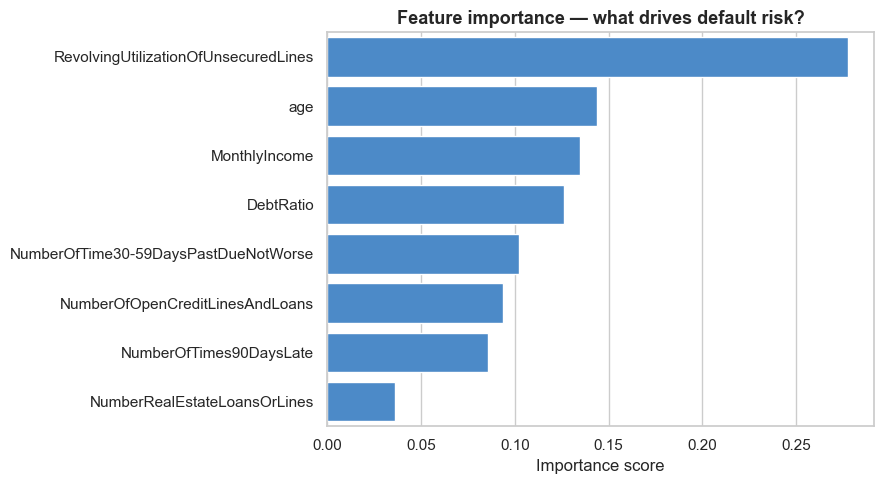

                             feature  importance
RevolvingUtilizationOfUnsecuredLines    0.277580
                                 age    0.143943
                       MonthlyIncome    0.134839
                           DebtRatio    0.126191
NumberOfTime30-59DaysPastDueNotWorse    0.102407
     NumberOfOpenCreditLinesAndLoans    0.093359
             NumberOfTimes90DaysLate    0.085494
        NumberRealEstateLoansOrLines    0.036187


In [26]:
# Which features matter most to the model?
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='importance', y='feature', color='#378ADD')
plt.title('Feature importance — what drives default risk?')
plt.xlabel('Importance score')
plt.ylabel('')
plt.tight_layout()
plt.savefig('E:/project/UK Banking Risk Intelligence Dashboard/outputs/feature_importance.png', dpi=150)
plt.show()

print(importance_df.to_string(index=False))

***Add risk score back to the dataset***

In [27]:
# Add the predicted probability (0 to 1) as a risk score
credit['default_risk_score'] = model.predict_proba(X)[:, 1]

# Categorise into Low / Medium / High risk
credit['risk_category'] = pd.cut(
    credit['default_risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Check the distribution
print(credit['risk_category'].value_counts())
print(credit[['age', 'MonthlyIncome', 'default_risk_score', 'risk_category']].head(10))

# Save the final file for Power BI
credit.to_csv('E:/project/UK Banking Risk Intelligence Dashboard/Cleaned_Dataset/credit_with_risk.csv', index=False)
print("credit_with_risk.csv saved successfully")

risk_category
Low Risk       72023
High Risk       7847
Medium Risk     2136
Name: count, dtype: int64
   age  MonthlyIncome  default_risk_score risk_category
0   45         9120.0                0.39   Medium Risk
1   40         2600.0                0.01      Low Risk
2   38         3042.0                0.15      Low Risk
3   30         3300.0                0.01      Low Risk
4   49        63588.0                0.07      Low Risk
5   74         3500.0                0.00           NaN
6   57         5400.0                0.03      Low Risk
7   39         3500.0                0.07      Low Risk
8   27         5400.0                0.00           NaN
9   57        23684.0                0.02      Low Risk
credit_with_risk.csv saved successfully


## How to read the model results

- **Precision** — of all customers predicted as defaulters, how many actually did?
- **Recall** — of all actual defaulters, how many did the model catch?
- **AUC Score** — overall model quality (0.5 = random, 1.0 = perfect)
- **Risk score** — probability between 0 and 1 (e.g. 0.82 = 82% likely to default)

### Key finding
The most important predictor is `RevolvingUtilizationOfUnsecuredLines`
— customers using more than 60% of their available credit are
significantly more likely to default, regardless of income level.

## Save the model To Use it later

In [28]:
import joblib

# Create a models folder
models_path = r'E:\project\UK Banking Risk Intelligence Dashboard\models'
os.makedirs(models_path, exist_ok=True)

# Save the model
joblib.dump(model, os.path.join(models_path, 'default_risk_model.pkl'))
print("Model saved successfully")

Model saved successfully


***Load the model***

In [29]:
import joblib

# Load the saved model (no need to retrain)
model = joblib.load(r'E:\project\UK Banking Risk Intelligence Dashboard\models\default_risk_model.pkl')
print("Model loaded successfully")

Model loaded successfully


***Use it on a single new customer***

In [30]:
# A new customer's details
new_customer = pd.DataFrame([{
    'RevolvingUtilizationOfUnsecuredLines': 0.75,   # using 75% of credit
    'age': 34,
    'NumberOfTime30-59DaysPastDueNotWorse': 2,
    'DebtRatio': 0.45,
    'MonthlyIncome': 3200,
    'NumberOfOpenCreditLinesAndLoans': 5,
    'NumberOfTimes90DaysLate': 1,
    'NumberRealEstateLoansOrLines': 0
}])

# Predict
risk_score = model.predict_proba(new_customer)[0][1]
risk_label = 'High Risk' if risk_score > 0.6 else 'Medium Risk' if risk_score > 0.3 else 'Low Risk'

print(f"Default risk score : {risk_score:.2%}")
print(f"Risk category      : {risk_label}")

Default risk score : 44.00%
Risk category      : Medium Risk
